# 05 — Stochastic Effects: Photon Shot Noise, LER & LWR

This notebook explores **stochastic effects** in EUV lithography:

1. **Photon shot noise** — discrete nature of EUV photons
2. **LER (Line Edge Roughness)** — edge position variations
3. **LWR (Line Width Roughness)** — width variations along a line
4. **1/√Dose scaling law** — fundamental photon-statistics limit
5. **Integration into the full simulation pipeline**

**Physical background:** At 13.5 nm (91.84 eV), EUV photons are scarce. At 20 mJ/cm² only 13.6 photons/nm² arrive, and a 50 nm film absorbs about one in five of them. Poisson statistics → relative uncertainty → LER/LWR.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euvsimulator.pipeline import SimulationConfig, run_simulation
from euvsimulator.resist.exposure import dose_to_acid
from euvsimulator.resist.peb import reaction_diffusion_analytical
from euvsimulator.resist.develop import threshold_development
from euvsimulator.resist.stochastic import (
    poisson_shot_noise,
    extract_edges,
    extract_ler,
    extract_lwr,
    ler_lwr_estimate,
    rms_scaling_check,
)


## 1. Photon Budget at EUV

- Photon energy: 91.84 eV = 1.47×10⁻¹⁷ J
- At 20 mJ/cm²: ~1.36×10¹⁵ photons/cm² ≈ 13.6 photons/nm²
- The standalone demonstration below uses 0.2 acids per incident photon: a 50 nm film absorbs about
  20 % of the photons and the chain yields about one acid per *absorbed* photon
  (`acids_per_absorbed_photon`, `docs/physics.md`), i.e. ≈ 2.7 acids per nm² at 20 mJ/cm²

**Poisson statistics:** σ/μ = 1/√N → huge relative uncertainty at low dose.


## 2. Deterministic Test Line (Absorbed Dose)

A dark line on an exposed background, as in a positive-tone resist: the dose is lowest in the
centre of the line. The map is kept in relative units (1 = open frame), so the Poisson noise
below acts on a linear quantity, and it has 1024 rows so that the roughness statistics have
enough samples.

In [2]:
n_rows, grid = 1024, 128
dx = 0.5  # nm/pixel
x = np.arange(grid) * dx
center = grid * dx / 2
line_profile = 1.0 - np.exp(-((x - center) / 10.0) ** 2)  # 0 in the line centre, 1 in the space

D0 = 20.0  # open-frame dose [mJ/cm²]
dose_map = torch.tensor(D0 * line_profile, dtype=torch.float64).unsqueeze(0).expand(n_rows, grid).clone()
acid = dose_map / D0  # relative acid, proportional to the absorbed dose (linear regime)

print(f"Map shape: {tuple(acid.shape)} (rows × columns, {dx} nm pixels)")
print(f"Relative dose range: {acid.min():.3f} – {acid.max():.3f}")

Map shape: (1024, 128) (rows × columns, 0.5 nm pixels)
Relative dose range: 0.000 – 1.000


## 3. Apply Poisson Shot Noise

Each pixel receives a Poisson-distributed number of acid-generating events with mean QE × N_ph,
where N_ph is the number of incident photons in the pixel. QE = 0.2 acids per incident photon
(≈ 20 % absorbed in 50 nm × ≈ 1 acid per absorbed photon).

In [3]:
rng = torch.Generator().manual_seed(42)
QE = 0.2  # acids per incident photon

noisy_acid, photon_count = poisson_shot_noise(
    acid, dose=dose_map, quantum_efficiency=QE, return_photon_count=True, rng=rng, dx_nm=dx,
)

print(f"Incident photons per pixel in the space: {photon_count.max():.2f}")
print(f"Acid events per pixel in the space:      {QE * photon_count.max():.2f}")
print(f"Mean relative acid: {acid.mean():.4f} (deterministic) vs {noisy_acid.mean():.4f} (noisy)")

Incident photons per pixel in the space: 3.40
Acid events per pixel in the space:      0.68
Mean relative acid: 0.7231 (deterministic) vs 0.7249 (noisy)


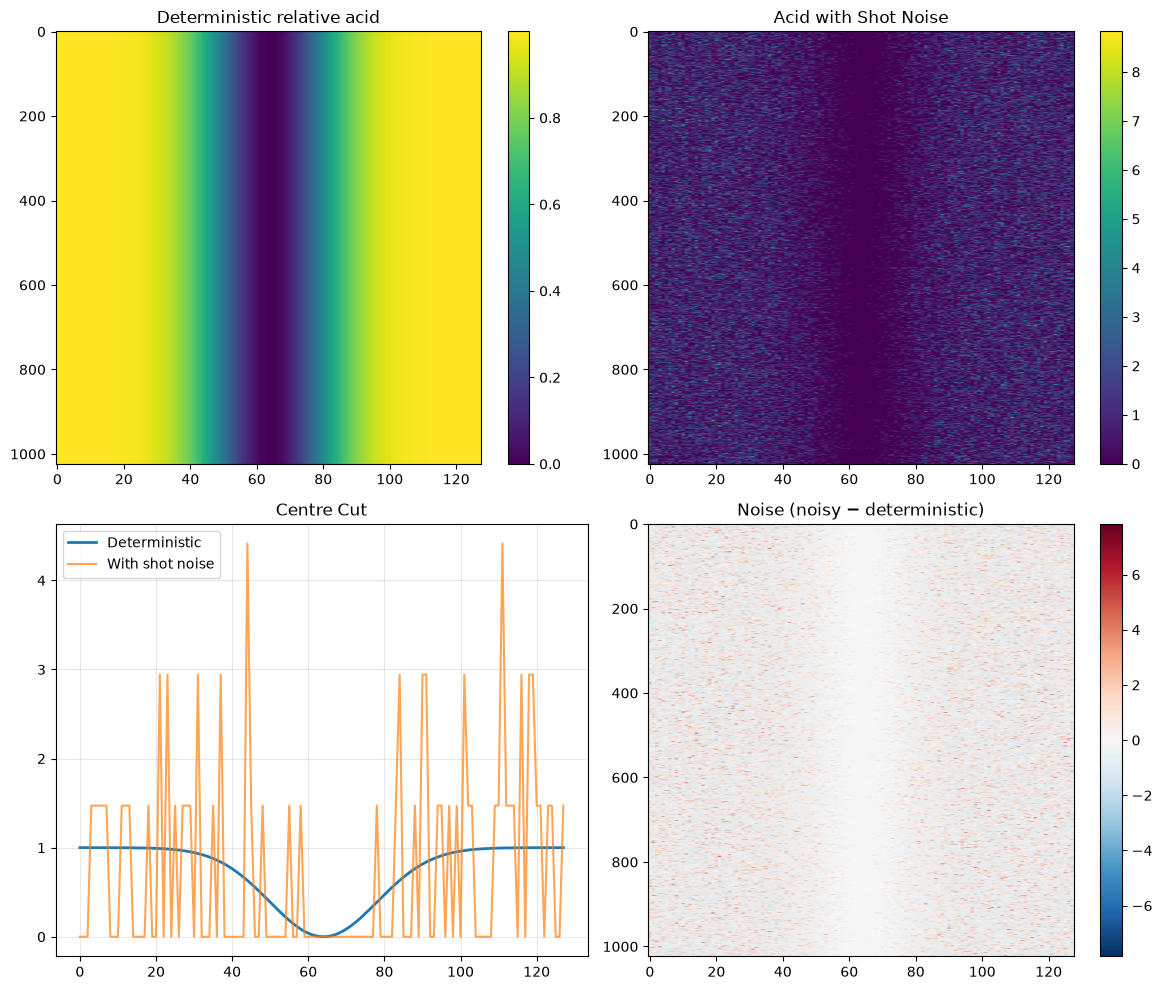

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(acid.numpy(), cmap="viridis", aspect="auto")
axes[0, 0].set_title("Deterministic relative acid")
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(noisy_acid.numpy(), cmap="viridis", aspect="auto")
axes[0, 1].set_title("Acid with Shot Noise")
plt.colorbar(im1, ax=axes[0, 1])

axes[1, 0].plot(acid[grid//2, :].numpy(), label="Deterministic", linewidth=2)
axes[1, 0].plot(noisy_acid[grid//2, :].numpy(), label="With shot noise", alpha=0.7)
axes[1, 0].set_title("Centre Cut")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

diff = (noisy_acid - acid).numpy()
v = np.abs(diff).max()
im2 = axes[1, 1].imshow(diff, cmap="RdBu_r", aspect="auto", vmin=-v, vmax=v)
axes[1, 1].set_title("Noise (noisy − deterministic)")
plt.colorbar(im2, ax=axes[1, 1])

plt.tight_layout()
plt.show()


## 4. Blur and Development → Contours

Secondary electrons and acid diffusion blur the acid map (one Gaussian with σ = 5 nm here). The
resist develops where the blurred acid exceeds half of the deterministic maximum; the line is the
region that stays below it.

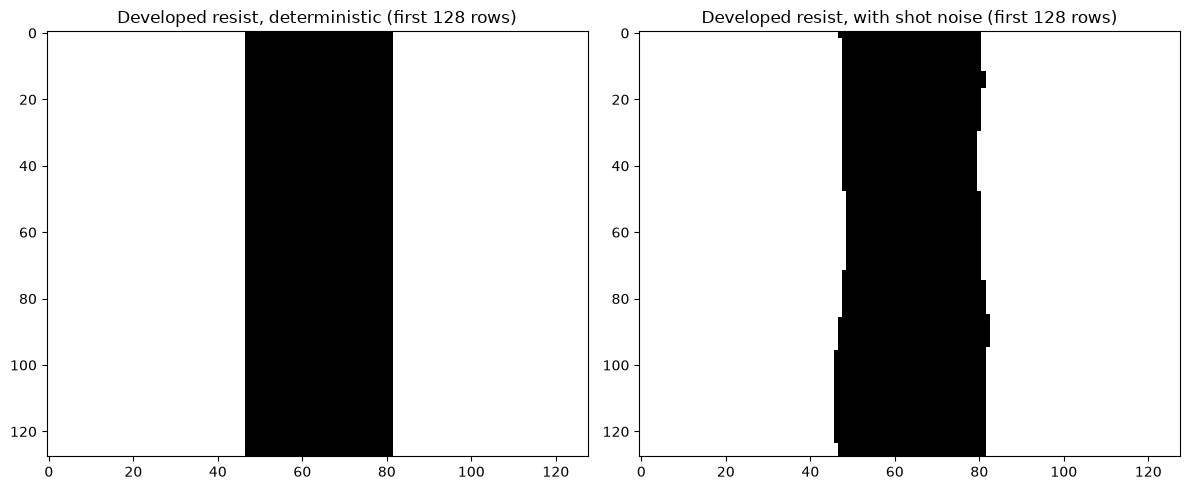

In [5]:
from euvsimulator.resist.exposure import gaussian_se_blur

BLUR = 5.0  # nm
det_b = gaussian_se_blur(acid, sigma=BLUR, dx=dx)
noisy_b = gaussian_se_blur(noisy_acid, sigma=BLUR, dx=dx)
THR = 0.5 * float(det_b.max())

dev_det = (det_b > THR).float()  # 1 = developed, 0 = resist line
dev_noisy = (noisy_b > THR).float()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(dev_det[:128].numpy(), cmap="gray", aspect="auto")
axes[0].set_title("Developed resist, deterministic (first 128 rows)")
axes[1].imshow(dev_noisy[:128].numpy(), cmap="gray", aspect="auto")
axes[1].set_title("Developed resist, with shot noise (first 128 rows)")
plt.tight_layout()
plt.show()

## 5. LER / LWR Extraction


In [6]:
left_edge, right_edge = extract_edges(noisy_b, threshold=THR, dx=dx, intensity=noisy_b)
ler = extract_ler(noisy_b, threshold=THR, dx=dx, intensity=noisy_b)
lwr = extract_lwr(noisy_b, threshold=THR, dx=dx, intensity=noisy_b)

print(f"LER: {ler:.3f} nm")
print(f"LWR: {lwr:.3f} nm")
print(f"LWR/LER ratio: {lwr / ler:.3f} (√2 ≈ 1.414 for uncorrelated edges)")

LER: 0.380 nm
LWR: 0.518 nm
LWR/LER ratio: 1.365 (√2 ≈ 1.414 for uncorrelated edges)


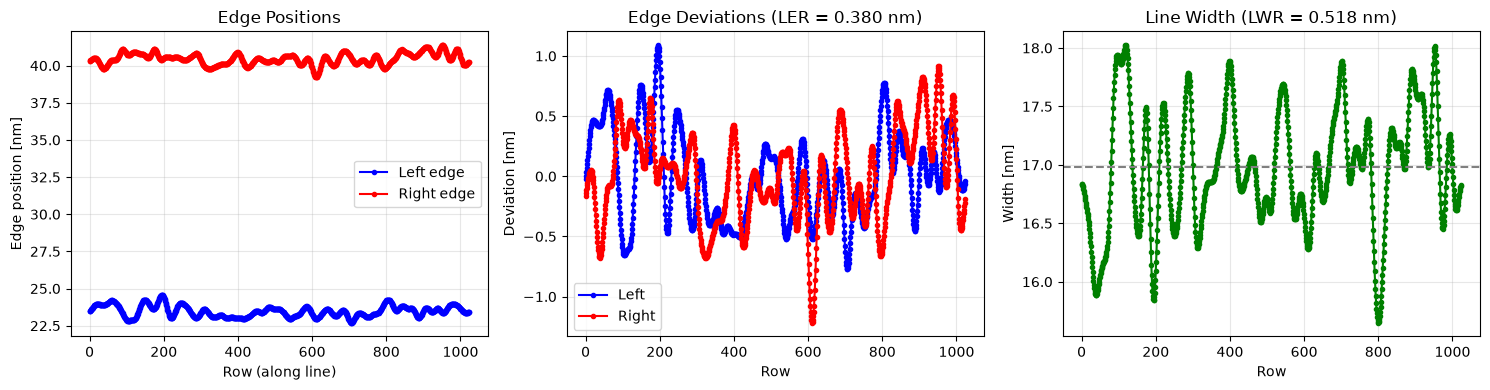

In [7]:
valid = ~(torch.isnan(left_edge) | torch.isnan(right_edge))
rows = torch.arange(left_edge.shape[0])[valid].numpy()
left_nm = left_edge[valid].numpy()
right_nm = right_edge[valid].numpy()
width_nm = right_nm - left_nm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rows, left_nm, "b.-", label="Left edge")
axes[0].plot(rows, right_nm, "r.-", label="Right edge")
axes[0].set_xlabel("Row (along line)")
axes[0].set_ylabel("Edge position [nm]")
axes[0].set_title("Edge Positions")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rows, left_nm - left_nm.mean(), "b.-", label="Left")
axes[1].plot(rows, right_nm - right_nm.mean(), "r.-", label="Right")
axes[1].set_xlabel("Row")
axes[1].set_ylabel("Deviation [nm]")
axes[1].set_title(f"Edge Deviations (LER = {ler:.3f} nm)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(rows, width_nm, "g.-")
axes[2].axhline(width_nm.mean(), color="gray", linestyle="--")
axes[2].set_xlabel("Row")
axes[2].set_ylabel("Width [nm]")
axes[2].set_title(f"Line Width (LWR = {lwr:.3f} nm)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Multiple Realisations → Statistics


LER: mean=0.421 nm, std=0.032 nm
LWR: mean=0.604 nm, std=0.089 nm


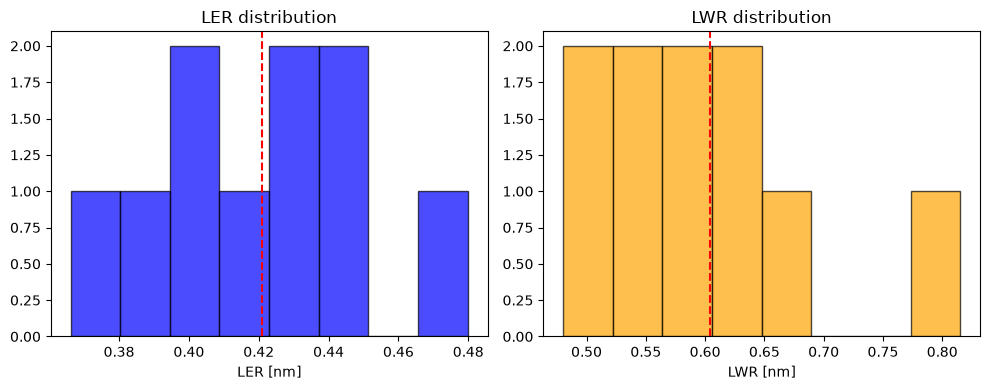

In [8]:
n_real = 10
ler_vals, lwr_vals = [], []

for i in range(n_real):
    rng_i = torch.Generator().manual_seed(1000 + i)
    noisy_i = poisson_shot_noise(acid, dose=dose_map, quantum_efficiency=QE, rng=rng_i, dx_nm=dx)
    b_i = gaussian_se_blur(noisy_i, sigma=BLUR, dx=dx)
    ler_vals.append(extract_ler(b_i, threshold=THR, dx=dx, intensity=b_i))
    lwr_vals.append(extract_lwr(b_i, threshold=THR, dx=dx, intensity=b_i))

ler_vals = np.array(ler_vals)
lwr_vals = np.array(lwr_vals)

print(f"LER: mean={ler_vals.mean():.3f} nm, std={ler_vals.std():.3f} nm")
print(f"LWR: mean={lwr_vals.mean():.3f} nm, std={lwr_vals.std():.3f} nm")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(ler_vals, bins=8, alpha=0.7, color="blue", edgecolor="black")
ax1.axvline(ler_vals.mean(), color="red", linestyle="--")
ax1.set_xlabel("LER [nm]"); ax1.set_title("LER distribution")
ax2.hist(lwr_vals, bins=8, alpha=0.7, color="orange", edgecolor="black")
ax2.axvline(lwr_vals.mean(), color="red", linestyle="--")
ax2.set_xlabel("LWR [nm]"); ax2.set_title("LWR distribution")
plt.tight_layout()
plt.show()

## 7. The 1/√Dose Scaling Law

Shot-noise-limited LER scales as 1/√D, the hallmark of Poisson statistics. In this demonstration it
holds by construction: pure shot noise, a linear response and a threshold at a fixed fraction of the
deterministic maximum, so the mean edge does not move with dose. Real resists add contributions
that do not scale with dose (Sections 8–10 and `docs/physics.md`).

Fit exponent: -0.546 (expect ≈ −0.5)
D =    5 mJ/cm²: LER 0.904 nm, LWR 1.257 nm, LER·√D 2.02
D =   10 mJ/cm²: LER 0.599 nm, LWR 0.845 nm, LER·√D 1.90
D =   20 mJ/cm²: LER 0.426 nm, LWR 0.606 nm, LER·√D 1.90
D =   40 mJ/cm²: LER 0.291 nm, LWR 0.420 nm, LER·√D 1.84
D =   80 mJ/cm²: LER 0.196 nm, LWR 0.287 nm, LER·√D 1.75


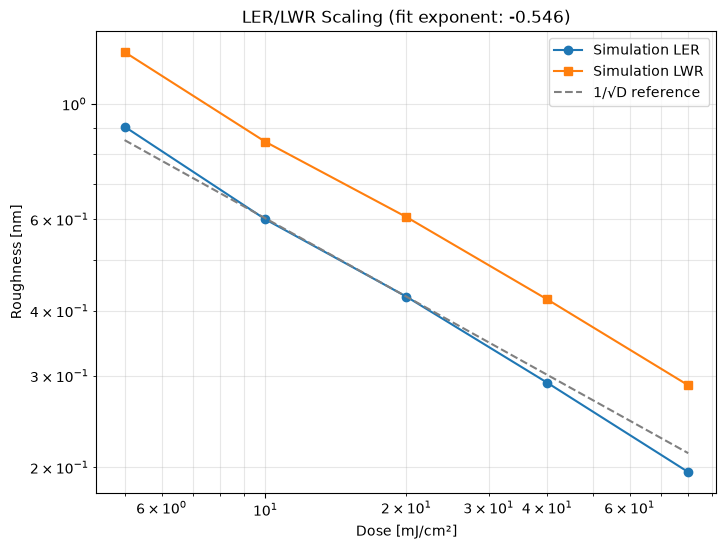

In [9]:
dose_levels = np.array([5, 10, 20, 40, 80], dtype=float)
ler_d, lwr_d = [], []

for D in dose_levels:
    dose_D = dose_map * (D / D0)
    vals = []
    for s in range(4):
        g = torch.Generator().manual_seed(2000 + s)
        n_D = poisson_shot_noise(acid, dose=dose_D, quantum_efficiency=QE, rng=g, dx_nm=dx)
        b_D = gaussian_se_blur(n_D, sigma=BLUR, dx=dx)
        vals.append((
            extract_ler(b_D, threshold=THR, dx=dx, intensity=b_D),
            extract_lwr(b_D, threshold=THR, dx=dx, intensity=b_D),
        ))
    ler_d.append(np.mean([v[0] for v in vals]))
    lwr_d.append(np.mean([v[1] for v in vals]))

ler_d, lwr_d = np.array(ler_d), np.array(lwr_d)
fit = float(np.polyfit(np.log(dose_levels), np.log(ler_d), 1)[0])
scaling = {
    "dose_levels": torch.tensor(dose_levels),
    "ler": torch.tensor(ler_d),
    "lwr": torch.tensor(lwr_d),
    "ler_sqrt_dose": torch.tensor(ler_d * np.sqrt(dose_levels)),
    "lwr_sqrt_dose": torch.tensor(lwr_d * np.sqrt(dose_levels)),
    "fit_dose_exponent": fit,
}

print(f"Fit exponent: {fit:.3f} (expect ≈ −0.5)")
for D, l, w in zip(dose_levels, ler_d, lwr_d):
    print(f"D = {D:4.0f} mJ/cm²: LER {l:.3f} nm, LWR {w:.3f} nm, LER·√D {l * np.sqrt(D):.2f}")

plt.figure(figsize=(8, 6))
plt.loglog(dose_levels, ler_d, "o-", label="Simulation LER")
plt.loglog(dose_levels, lwr_d, "s-", label="Simulation LWR")
plt.loglog(dose_levels, ler_d[2] * np.sqrt(dose_levels[2] / dose_levels), "--", color="gray", label="1/√D reference")
plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("Roughness [nm]")
plt.title(f"LER/LWR Scaling (fit exponent: {fit:.3f})")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

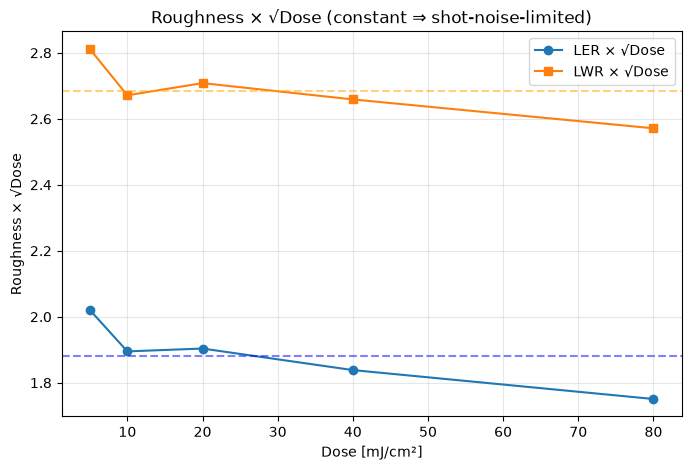

In [10]:
# LER × √Dose should be constant
plt.figure(figsize=(8, 5))
plt.plot(scaling["dose_levels"].numpy(), scaling["ler_sqrt_dose"].numpy(), "o-", label="LER × √Dose")
plt.plot(scaling["dose_levels"].numpy(), scaling["lwr_sqrt_dose"].numpy(), "s-", label="LWR × √Dose")
plt.axhline(scaling["ler_sqrt_dose"].mean().item(), color="blue", linestyle="--", alpha=0.5)
plt.axhline(scaling["lwr_sqrt_dose"].mean().item(), color="orange", linestyle="--", alpha=0.5)
plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("Roughness × √Dose")
plt.title("Roughness × √Dose (constant ⇒ shot-noise-limited)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Full Pipeline: `enable_stochastic=True`


In [11]:
cfg = SimulationConfig(
    period_nm=64.0,
    line_width_nm=32.0,
    # Dose is the WAFER dose in a clear area (Mack 1997 convention). The default resist prints
    # the 32 nm line at about 1.3 mJ/cm² (dose-to-size at grid 128). The PEB blur is the chain's
    # own default (σ ≈ 7.9 nm); the SE blur is set to 5 nm here (default 2.5 nm).
    dose_mj_cm2=1.3,
    resist_model="full_chem",
    enable_stochastic=True,
    stochastic_n_realisations=5,
    stochastic_seed=42,
    grid=128,
    se_blur_nm=5.0,
)

result = run_simulation(cfg)

print(f"CD:   {result.cd_nm:.2f} nm")
print(f"NILS: {result.nils_value:.3f}")
print(f"LER:  {result.ler_nm:.3f} nm")
print(f"LWR:  {result.lwr_nm:.3f} nm")

CD:   32.06 nm
NILS: 3.937
LER:  2.013 nm
LWR:  3.446 nm


## 9. Dose Dependence via the Full Pipeline


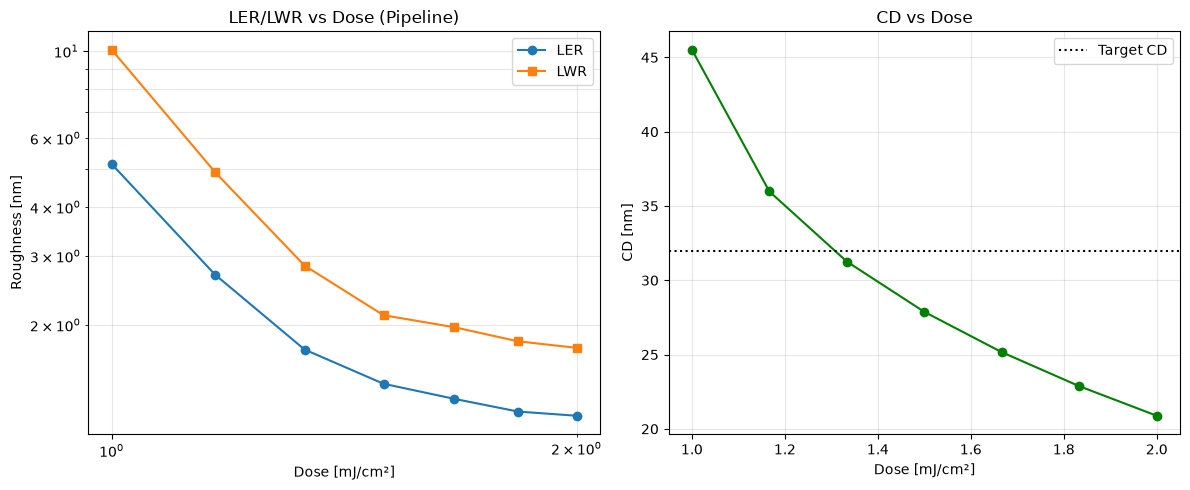

In [12]:
# Dose window of the default resist (wafer-dose convention, Eikonal development): the 32 nm
# line prints at 1.3 mJ/cm²; from 1.0 to 2.0 mJ/cm² its CD falls from about 45 to 21 nm.
doses_pipe = np.linspace(1.0, 2.0, 7)
ler_pipe, lwr_pipe, cd_pipe = [], [], []

for d in doses_pipe:
    cfg = SimulationConfig(
        period_nm=64.0, line_width_nm=32.0, dose_mj_cm2=d,
        resist_model="full_chem", enable_stochastic=True,
        stochastic_n_realisations=3, stochastic_seed=42,
        grid=128, se_blur_nm=5.0,
    )
    r = run_simulation(cfg)
    ler_pipe.append(r.ler_nm)
    lwr_pipe.append(r.lwr_nm)
    cd_pipe.append(r.cd_nm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.loglog(doses_pipe, ler_pipe, "o-", label="LER")
ax1.loglog(doses_pipe, lwr_pipe, "s-", label="LWR")
ax1.set_xlabel("Dose [mJ/cm²]"); ax1.set_ylabel("Roughness [nm]")
ax1.set_title("LER/LWR vs Dose (Pipeline)")
ax1.legend(); ax1.grid(True, alpha=0.3, which="both")

ax2.plot(doses_pipe, cd_pipe, "o-", color="green")
ax2.axhline(32.0, color="k", linestyle=":", label="Target CD")
ax2.set_xlabel("Dose [mJ/cm²]"); ax2.set_ylabel("CD [nm]")
ax2.set_title("CD vs Dose")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Resist Sensitivity (Dill C) Impact

`dill_C` [cm²/mJ] is the resist's photo-rate constant. In an EUV chemically amplified
resist it already contains the PAG quantum efficiency: Mack's EUV exposure model
(2013, Eqs. 8 and 10) gives the acid yield as 1 − exp(−C·E) with φ_PAG a factor *inside* C
and no separate prefactor. (A former `dill_Q` factor that multiplied this yield double-counted
φ_PAG and was removed on 2026-09-04 -- see `docs/audit_2026-09-04_vollpruefung.md`, A5.)

Under **pure photon shot noise** `dill_C` only shifts the mean acid level / dose-response
curve. Its effect on molecular-count noise exists only in the **`exposure_stochasticity=True`**
path (PAG/quencher molecular discreteness), which samples a Poisson-distributed PAG population
and a Binomial conversion per voxel with probability 1 − exp(−C·E) --
see `resist/exposure.py::sample_pag_quencher_acid()`.

**Honest caveats:**

1. **Dose is held fixed** while `dill_C` varies, so the mean CD drifts across the sweep. The
   LER trend is therefore a mix of the sensitivity effect *and* whatever CD/geometry itself
   does to roughness -- it is **not** an isolated measurement (that would need a
   dose-to-size sweep, matching CD at each C).
2. **The sweep stays inside the printing window**: C is varied by −20 %…+20 % around the default
   0.0152 cm²/mJ at the dose-to-size (1.3 mJ/cm²), which moves the CD from about 42 to 27 nm.
   Much larger C at this dose clears the film completely (CD = 0, nothing to measure); much
   smaller C leaves it undeveloped (CD = full period).


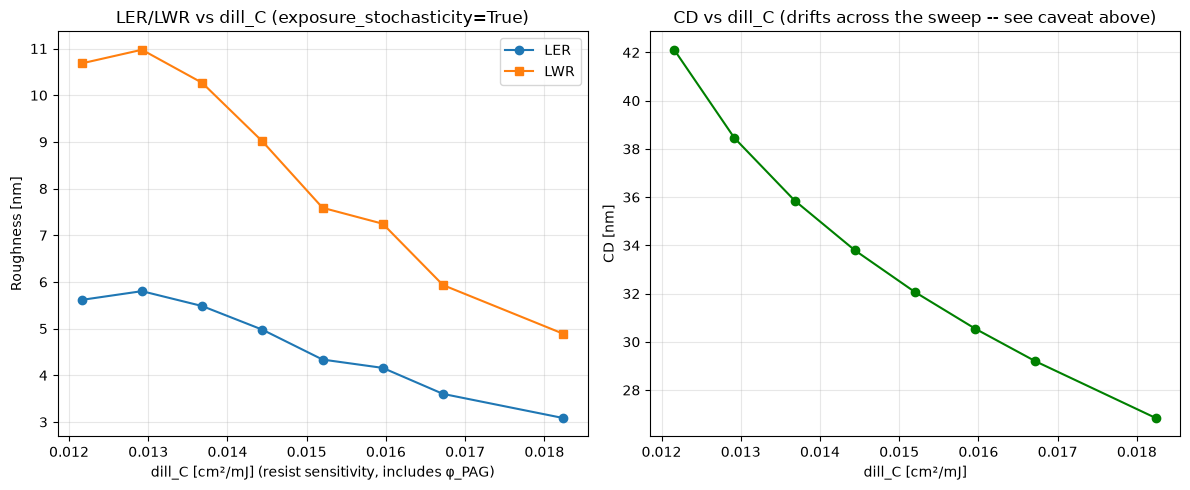

0 of 8 points had no measurable edge (NaN, excluded from the roughness plot).


In [13]:
c_vals = 0.0152 * np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20])  # around the default C
ler_c, lwr_c, cd_c = [], [], []

for c in c_vals:
    cfg = SimulationConfig(
        period_nm=64.0, line_width_nm=32.0, dose_mj_cm2=1.3,
        resist_model="full_chem", enable_stochastic=True,
        stochastic_n_realisations=3, dill_C=float(c), exposure_stochasticity=True,
        stochastic_seed=42, grid=128, se_blur_nm=5.0,
    )
    r = run_simulation(cfg)
    ler_c.append(r.ler_nm)
    lwr_c.append(r.lwr_nm)
    cd_c.append(r.cd_nm)

ler_c = np.array(ler_c)
lwr_c = np.array(lwr_c)
cd_c = np.array(cd_c)
valid = ~np.isnan(ler_c)  # exclude points where no realization had a measurable edge

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(c_vals[valid], ler_c[valid], "o-", label="LER")
ax1.plot(c_vals[valid], lwr_c[valid], "s-", label="LWR")
ax1.set_xlabel("dill_C [cm²/mJ] (resist sensitivity, includes φ_PAG)")
ax1.set_ylabel("Roughness [nm]")
ax1.set_title("LER/LWR vs dill_C (exposure_stochasticity=True)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(c_vals, cd_c, "o-", color="green")
ax2.set_xlabel("dill_C [cm²/mJ]"); ax2.set_ylabel("CD [nm]")
ax2.set_title("CD vs dill_C (drifts across the sweep -- see caveat above)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{(~valid).sum()} of {len(c_vals)} points had no measurable edge (NaN, excluded from the roughness plot).")


## Summary

| Parameter | Effect on LER/LWR |
|-----------|-------------------|
| **Dose** | LER roughly decreases with dose within the resolvable window (Section 9 above) -- not a clean 1/√Dose power law under the full depth-resolved Dill+PEB+Mack chain used here (see `docs/claude_code_arbeitslog.md` for why: `mack_n`'s steepness makes the CD-vs-dose response highly non-linear near the resolution edge) |
| **dill_C (sensitivity)** | Section 10: roughness varies with `dill_C` (±20 % around the default), but confounded with CD drift (dose held fixed) -- see caveats above, not an isolated measurement |
| **SE blur** | Smears the dose map -> changes the effective spatial correlation of the roughness (see Sections 1-8 above) |
| **exposure_stochasticity** | The physically distinct mechanism actually responsible for QE/PAG-count-driven roughness (Section 10, PAG-count noise); OFF by default, only active when explicitly enabled |

**What this notebook does *not* claim:** a validated, isolated 1/√dose power law under
the current full_chem resist chain. The classic shot-noise scaling law (Sections 1-7) is a
textbook Poisson-statistics result and is demonstrated there on a simplified, standalone
acid map; Sections 8-10, which run the *full* pipeline (depth-resolved Dill exposure, PEB
reaction-diffusion, Mack development front), show real but messier behavior -- narrow
resolution windows and non-power-law dose/sensitivity dependence are honest findings about this
resist model, not something to average away.

**CLI usage (flags verified 2026-09-11 against `euv simulate --help`; dose is the wafer dose in a clear area):**
```bash
euv simulate --resist-model full_chem --stochastic \
  --stochastic-realisations 10 --stochastic-seed 42 \
  --dose 1.3 --se-blur 5
```
(`exposure_stochasticity` and the PAG/quencher-density parameters are not yet exposed as
CLI flags -- only reachable via the Python API, `SimulationConfig(exposure_stochasticity=True, ...)`.)
